<a href="https://colab.research.google.com/github/njwbilll/Tugas-5_Grokking-Deep-Learning-MANNING_Najwa-Bilqis-Al-Khalidah/blob/main/07_How_Do_Neural_Networks_Really_Learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Chapter 7: How Do Neural Networks Really Learn?

## Ringkasan Chapter

Bab 7 berfokus pada pemahaman mendalam mengenai proses pembelajaran neural network. Jika pada bab sebelumnya diperkenalkan backpropagation, pada bab ini dijelaskan mengapa gradient descent bekerja dan bagaimana bobot diperbarui untuk meminimalkan error.

Topik utama:

1. Gradient Descent
2. Direction and Amount
3. Derivatives
4. Chain Rule
5. Gradient Calculation
6. Weight Updates
7. Error Surface
8. Learning Rate
9. Local dan Global Minimum
10. Implementasi Training dari Awal

Bab ini merupakan fondasi matematika yang sangat penting sebelum mempelajari arsitektur neural network yang lebih kompleks.


In [ ]:

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(1)



## 1. Mengapa Neural Network Bisa Belajar

Neural network belajar karena memiliki mekanisme untuk mengukur kesalahan dan memperbaiki dirinya sendiri.

Alur umum:

Input

→ Prediksi

→ Hitung Error

→ Hitung Gradient

→ Update Bobot

→ Prediksi Baru

Proses ini diulang berkali kali hingga error semakin kecil.


In [ ]:

weight = 0.5
input_value = 2
target = 0.8

prediction = input_value * weight
error = (prediction - target) ** 2

print("Prediction:", prediction)
print("Error:", error)


Prediction: 1.0
Error: 0.03999999999999998



## 2. Konsep Gradient

Gradient menunjukkan arah tercepat untuk menurunkan error.

Jika error meningkat ketika bobot dinaikkan, maka bobot harus diturunkan.

Jika error menurun ketika bobot dinaikkan, maka bobot harus dinaikkan.

Inilah ide utama gradient descent.


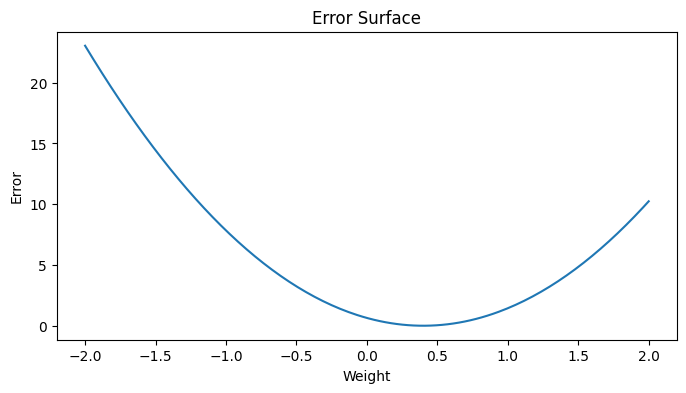

In [ ]:

weights = np.linspace(-2,2,200)
errors = []

for w in weights:
    pred = input_value * w
    err = (pred - target) ** 2
    errors.append(err)

plt.figure(figsize=(8,4))
plt.plot(weights, errors)
plt.title("Error Surface")
plt.xlabel("Weight")
plt.ylabel("Error")
plt.show()



## 3. Turunan (Derivative)

Turunan mengukur seberapa cepat suatu fungsi berubah.

Dalam neural network:

Derivative memberi tahu seberapa sensitif error terhadap perubahan bobot.

Semakin besar derivative, semakin besar pengaruh perubahan bobot terhadap error.


In [ ]:

def derivative(weight, x, target):
    prediction = x * weight
    return 2 * (prediction - target) * x

print(derivative(0.5, 2, 0.8))


0.7999999999999998



## 4. Gradient Descent

Rumus dasar:

new_weight = old_weight - learning_rate × gradient

Tujuan update adalah bergerak menuju titik dengan error yang lebih kecil.


In [ ]:

weight = 0.5
alpha = 0.1

for iteration in range(10):

    prediction = input_value * weight
    error = (prediction - target) ** 2

    grad = 2 * (prediction - target) * input_value

    weight -= alpha * grad

    print(
        "Iter:", iteration,
        "Weight:", round(weight,4),
        "Error:", round(error,6)
    )


Iter: 0 Weight: 0.42 Error: 0.04
Iter: 1 Weight: 0.404 Error: 0.0016
Iter: 2 Weight: 0.4008 Error: 6.4e-05
Iter: 3 Weight: 0.4002 Error: 3e-06
Iter: 4 Weight: 0.4 Error: 0.0
Iter: 5 Weight: 0.4 Error: 0.0
Iter: 6 Weight: 0.4 Error: 0.0
Iter: 7 Weight: 0.4 Error: 0.0
Iter: 8 Weight: 0.4 Error: 0.0
Iter: 9 Weight: 0.4 Error: 0.0



## 5. Learning Rate

Learning rate mengontrol ukuran langkah saat update bobot.

Terlalu kecil:

Training lambat.

Terlalu besar:

Training tidak stabil dan dapat melewati minimum.


In [ ]:

learning_rates = [0.01, 0.1, 1.0]

for lr in learning_rates:

    weight = 0.5

    for _ in range(20):
        prediction = input_value * weight
        grad = 2 * (prediction - target) * input_value
        weight -= lr * grad

    print("Learning Rate:", lr, "Final Weight:", round(weight,4))


Learning Rate: 0.01 Final Weight: 0.4189
Learning Rate: 0.1 Final Weight: 0.4
Learning Rate: 1.0 Final Weight: 7979226629761197.0



## 6. Chain Rule

Chain Rule adalah fondasi matematis backpropagation.

Misalkan:

Input → Hidden Layer → Output

Error bergantung pada output.

Output bergantung pada hidden layer.

Hidden layer bergantung pada bobot.

Maka perubahan error terhadap bobot dihitung dengan mengalikan seluruh turunan tersebut.



## 7. Neural Network Sederhana

Berikut implementasi neural network satu layer yang dilatih menggunakan gradient descent.


In [ ]:

inputs = np.array([1,2,3,4])
targets = np.array([2,4,6,8])

weight = np.random.randn()

alpha = 0.01

for epoch in range(200):

    predictions = inputs * weight

    error = predictions - targets

    mse = np.mean(error ** 2)

    gradient = np.mean(2 * error * inputs)

    weight -= alpha * gradient

    if epoch % 20 == 0:
        print(epoch, round(mse,6))


0 1.058373
20 0.00159
40 2e-06
60 0.0
80 0.0
100 0.0
120 0.0
140 0.0
160 0.0
180 0.0



## 8. Visualisasi Konvergensi

Semakin banyak iterasi, error biasanya semakin kecil hingga mendekati minimum.


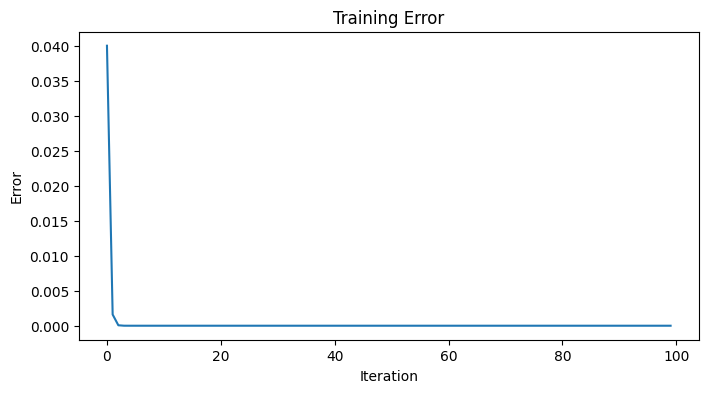

In [ ]:

weight = 0.5

history = []

for epoch in range(100):

    prediction = input_value * weight

    error = (prediction - target) ** 2

    gradient = 2 * (prediction - target) * input_value

    weight -= 0.1 * gradient

    history.append(error)

plt.figure(figsize=(8,4))
plt.plot(history)
plt.title("Training Error")
plt.xlabel("Iteration")
plt.ylabel("Error")
plt.show()



## 9. Local Minimum dan Global Minimum

Global minimum adalah titik dengan error terkecil secara keseluruhan.

Local minimum adalah titik minimum lokal yang belum tentu merupakan solusi terbaik.

Pada neural network modern, optimisasi sering dilakukan pada ruang parameter berdimensi sangat tinggi sehingga konsep ini menjadi penting.



## 10. Ringkasan Chapter 7

Konsep penting:

1. Neural network belajar dengan mengurangi error.
2. Gradient menunjukkan arah perubahan terbaik.
3. Derivative mengukur sensitivitas perubahan.
4. Gradient descent memperbarui bobot.
5. Learning rate menentukan ukuran langkah.
6. Chain rule memungkinkan backpropagation.
7. Error surface membantu memahami proses optimisasi.
8. Training dilakukan secara iteratif hingga konvergen.

Bab ini menjadi dasar matematis bagi seluruh algoritma deep learning modern.
